# **Density forecasts and economic applications**

**MSc thesis Euan Bronsky**

**Notebook number: 5**

This notebook focuses on the risk-neutral density forecasting and the economic evaluation. For the density forecasting, several scores are computed after which pairwise Diebold-Mariano tests distinguish the statistical superiority of the competing specifications.

--------------------------------------

- **Import dependencies**

In [1]:
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy.stats import norm
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import UnivariateSpline
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import chi2
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

- **Load the data**

In [2]:
# Load the evaluation results**
with open("/Users/euanbronsky/PyCharmMiscProject/models.eval.pkl", "rb") as f:
    eval_results = pickle.load(f)

# **1. Risk-neutral densities**
----------------------------------------

The risk-neutral densities are obtained following the result of Breeden and Litzenberger (1978), which links the second derivative of the call price with respect to strike to the risk-neutral density. For each evaluation date $t$ and maturity $\tau$, the estimated density at strike $K_g$ is given by

\begin{equation}
\hat{f}_{t\mid t-1,T}(K_g,\cdot)
=
e^{r\tau}
\frac{\partial^2 \hat{C}_{t\mid t-1,T}(K_g,\cdot)}
{\partial K^2}.
\end{equation}

Since the option quotes are not located on an equally spaced strike grid, the second derivative cannot be approximated using the standard equally spaced central-difference formula. Instead, an unequal grid finite-difference approximation is used after the option prices are smoothed. For an interior strike point $K_g$, this is given by

$$\frac{\partial^2 \hat{C}_{t\mid t-1,T}(K_g,\!\cdot)}{\partial K^2}
\approx
\frac{2}{K_{g+1} - K_{g-1}}
\left[
\frac{\hat{C}_{t\mid t-1,T}(K_{g+1},\!\cdot) - \hat{C}_{t\mid t-1,T}(K_g,\!\cdot)}
{K_{g+1} - K_g}
-
\frac{\hat{C}_{t\mid t-1,T}(K_g,\!\cdot) - \hat{C}_{t\mid t-1,T}(K_{g-1},\!\cdot)}
{K_g - K_{g-1}}
\right].$$

The density forecasting accuracy is assessed using the log-density score (LDS) and the continuous ranked probability score (CRPS). In particular, $LDS_{t, T} = -\log \hat q_{t,T}(S_{T})$, and

\begin{equation}
    CRPS_{t\mid t-1,T} = \int^\infty_{-\infty} \bigl(\hat G_{t\mid t-1,T}(x) - \mathbb{I}\{ S_{T} \leq x\}\bigr)^2dx.
\end{equation}



- **Compute the RND and corresponding scores**

In [3]:
# Risk-neutral density scores function
def rnd_scores(g):

    # Ensure one row per strike before finite differences
    g = (g.groupby("strike", as_index=False).agg({
            "call_pred": "mean",
            "r": "first",
            "T": "first",
            "underlying_last": "first",
            "S_realized": "first"})
        .sort_values("strike")
        .reset_index(drop=True))

    # Need enough strikes for smoothing and differentiation
    if len(g) < 5:
        return pd.Series({"LDS": np.nan, "CRPS": np.nan})

    # Extract strike and call-price arrays
    K = g["strike"].to_numpy()
    C = g["call_pred"].to_numpy()

    # Smooth the call-price curve before taking the second derivative
    smooth_factor = 1e-4 * len(g) * np.var(C)
    call_spline = UnivariateSpline(K, C, s = smooth_factor, k=3)

    # Replace raw call prices by smoothed call prices
    g["call_pred"] = call_spline(K)

    # Create neighboring values for finite differences
    g["C_prev"] = g["call_pred"].shift(1)
    g["C_next"] = g["call_pred"].shift(-1)
    g["K_prev"] = g["strike"].shift(1)
    g["K_next"] = g["strike"].shift(-1)

    # Drop boundary observations
    g = g.dropna().copy()

    # Ensure valid observations
    if len(g) == 0:
        return pd.Series({"LDS": np.nan, "CRPS": np.nan})

    # Compute slope of the call-price curve
    left_slope = (g["call_pred"] - g["C_prev"]) / (g["strike"] - g["K_prev"])
    right_slope = (g["C_next"] - g["call_pred"]) / (g["K_next"] - g["strike"])

    # Convert into risk-neutral density using unequal-grid finite differences
    g["density"] = (np.exp(g["r"].iloc[0] * g["T"].iloc[0]) * 2 * (right_slope - left_slope) / (g["K_next"] - g["K_prev"]))

    # Enforce valid non-negative density
    g["density"] = np.maximum(g["density"], 0)

    # Approximate total probability mass
    total_mass = np.trapezoid(g["density"], g["strike"])

    # Ensure valid mass
    if total_mass <= 0:
        return pd.Series({"LDS": np.nan, "CRPS": np.nan})

    # Normalize so total mass equals one
    g["density"] = g["density"] / total_mass

    # Construct CDF
    g["cdf"] = cumulative_trapezoid(g["density"], g["strike"], initial=0)
    g["cdf"] = g["cdf"] / g["cdf"].iloc[-1]

    # Realized underlying value
    S1 = g["S_realized"].iloc[0]

    # Skip if realized value is outside strike range
    if S1 < g["strike"].min() or S1 > g["strike"].max():
        return pd.Series({"LDS": np.nan, "CRPS": np.nan})

    # Density at realized value
    density_at_S1 = np.interp(S1, g["strike"], g["density"], left=1e-12, right=1e-12)

    # Compute LDS and CRPS
    LDS = -np.log(max(density_at_S1, 1e-12))
    realized_cdf = (S1 <= g["strike"]).astype(int)
    CRPS = np.trapezoid((g["cdf"] - realized_cdf) ** 2, g["strike"])

    # Return the results
    return pd.Series({
        "LDS": LDS,
        "CRPS": CRPS,})

- **Compute scores**

In [4]:
# Prepare data and apply previous function
def compute_rnd_scores(x_test, iv_pred):

    # Take test DF and add to model's predicted IVs
    df = x_test.copy().reset_index(drop=True)
    df["iv_pred"] = np.asarray(iv_pred, dtype=float)

    # Ensure datetime variables
    df["quote_date"] = pd.to_datetime(df["quote_date"])
    df["expire_date"] = pd.to_datetime(df["expire_date"])

    # Find realized underlying price at expiry date
    spot = (
        df[["quote_date", "underlying_last"]]
        .drop_duplicates("quote_date")
        .rename(columns={
            "quote_date": "expire_date",
            "underlying_last": "S_realized"}))

    # Merge to DF
    df = df.merge(spot, on="expire_date", how="left")
    df = df.dropna(subset=["S_realized"])

    # Compute BS components
    d1 = (np.log(df["underlying_last"] / df["strike"]) + (df["r"] - df["q"] + 0.5 * df["iv_pred"] ** 2) * df["T"]) / (df["iv_pred"] * np.sqrt(df["T"]))
    d2 = d1 - df["iv_pred"] * np.sqrt(df["T"])

    # Compute BS call prediction
    df["call_pred"] = (df["underlying_last"] * np.exp(-df["q"] * df["T"]) * norm.cdf(d1) - df["strike"] * np.exp(-df["r"] * df["T"]) * norm.cdf(d2))

    # Apply the previous function to obtain scores
    scores = (df.groupby(["quote_date", "expire_date"]).apply(rnd_scores).dropna())

    # Return the results
    return scores

- **Obtain results**

In [5]:
# Create empty dictionary
rnd_results = {}

# Compute the scores
for name, (x_test, iv_pred) in eval_results.items():
    rnd_results[name] = compute_rnd_scores(x_test, iv_pred)

# Store common index
common_idx = rnd_results["VAR"].index

# Ensure common index adheres to every model
for name in rnd_results:
    common_idx = common_idx.intersection(rnd_results[name].index)

# Filter each model to have the same indexes
for name in rnd_results:
    rnd_results[name] = rnd_results[name].loc[common_idx]

# Create dataframe with results and display
rnd_summary = pd.DataFrame({
    name: rnd_results[name].groupby(level="quote_date").mean().mean()
    for name in rnd_results
}).T
rnd_summary

,LDS,CRPS
Basic,6.961241,204.269292
VAR,6.848958,148.164311
OU,6.841184,142.772313
Spline,6.815856,139.873773
NN,6.805199,138.677214


- **Diebold-Mariano test**

In [6]:
# Diebold-Mariano test
def dm_test_loss(loss_model, loss_benchmark, lag=5):

    # Compute the loss differential
    loss_diff = np.asarray(loss_model) - np.asarray(loss_benchmark)

    # Length of the series, mean differential, and demean
    T = len(loss_diff)
    d_bar = np.mean(loss_diff)
    u = loss_diff - d_bar

    # Average squared deviation
    lrv = np.mean(u * u)

    # HAC standard errors
    for j in range(1, lag + 1):

        # Compute gamma and autocovariance corrections
        gamma = np.mean(u[j:] * u[:-j])
        lrv += 2 * (1 - j / (lag + 1)) * gamma

    # Compute standard error, test statistic, and p-value
    se = np.sqrt(lrv / T)
    dm_stat = d_bar / se
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))

    # Return the results
    return dm_stat, p_value

- **Diebold-Mariano table**

In [7]:
# DM table
def dm_table(loss_df, benchmark="VAR", lag=5):

    # Create empty list
    out = []

    # Loop over all models in the loss DF
    for name in loss_df.columns:

        # Skip the benchmark model itself
        if name == benchmark:
            continue

        # Run the DM test
        dm_stat, p_value = dm_test_loss(
            loss_df[name].to_numpy(),
            loss_df[benchmark].to_numpy(),
            lag=lag)

        # Append result to list
        out.append([name, dm_stat, p_value])

    # Return the results
    return pd.DataFrame(out, columns=["model", "DM statistic", "p-value"])

- **Compute DM LDS statistic**

In [8]:
# Create DataFrame with test results
crps_df = pd.DataFrame({
    name: rnd_results[name]["CRPS"]
    for name in rnd_results})

# Make table of results and display
dm_nn_crps = dm_table(crps_df, benchmark="NN", lag=5)
dm_nn_crps

,model,DM statistic,p-value
0,Basic,26.867299,0.0
1,VAR,16.291677,0.0
2,OU,25.960388,0.0
3,Spline,14.188946,0.0


- **Compute DM CRPS statistic**

In [9]:
# Create DataFrame with test results
lds_df = pd.DataFrame({
    name: rnd_results[name]["LDS"]
    for name in rnd_results})

# Create table of results and display
dm_nn_lds = dm_table(lds_df, benchmark="NN", lag=5)
dm_nn_lds

,model,DM statistic,p-value
0,Basic,21.366994,0.000000e+00
1,VAR,7.376639,1.623146e-13
2,OU,6.529934,6.579848e-11
3,Spline,3.064650,2.179247e-03


- **Helper function**

In [10]:
# Significance stars helper function
def significance_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

- **Pairwise DM test function**

In [11]:
# Pairwise Diebold-Mariano test function
def pairwise_dm_matrices(losses, lag=5):

    # Extract model names
    names = list(losses.keys())

    # Create empty square DataFrames
    dm_mat = pd.DataFrame(index=names, columns=names, dtype=float)
    p_mat = pd.DataFrame(index=names, columns=names, dtype=float)

    # Loop over model pairs
    for i in names:
        for j in names:

            # Diagonal is empty
            if i == j:
                dm_mat.loc[i, j] = np.nan
                p_mat.loc[i, j] = np.nan

            else:
                # Obtain common index
                common = losses[i].index.intersection(losses[j].index)

                # Apply DM test
                dm_stat, p_value = dm_test_loss(
                    losses[i].loc[common].to_numpy(),
                    losses[j].loc[common].to_numpy(),
                    lag=lag
                )

                # Store results
                dm_mat.loc[i, j] = dm_stat
                p_mat.loc[i, j] = p_value

    # Return the results
    return dm_mat, p_mat, names


- **Heatmap drawing function**

In [12]:
# Heatmap drawing function
def add_dm_heatmap(ax, dm_mat, p_mat, names, title, cmap):

    # Symmetric color scale around zero
    v = np.nanmax(np.abs(dm_mat.to_numpy(dtype=float)))
    color_norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)

    # Draw heatmap
    im = ax.imshow(dm_mat.astype(float), cmap=cmap, norm=color_norm)

    # Axis labels
    ax.set_xticks(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticklabels(names)

    # Add values inside cells
    for r in range(len(names)):
        for c in range(len(names)):

            if pd.isna(dm_mat.iloc[r, c]):
                ax.text(c, r, "-", ha="center", va="center", fontsize=8)

            else:
                p = p_mat.iloc[r, c]
                stars = significance_stars(p)

                ax.text(c, r, f"{dm_mat.iloc[r, c]:.2f}{stars}\n({p:.3f})", ha="center", va="center", fontsize=8)

    # Set a title
    ax.set_title(title)

    # Return the result
    return im

- **Display the results**

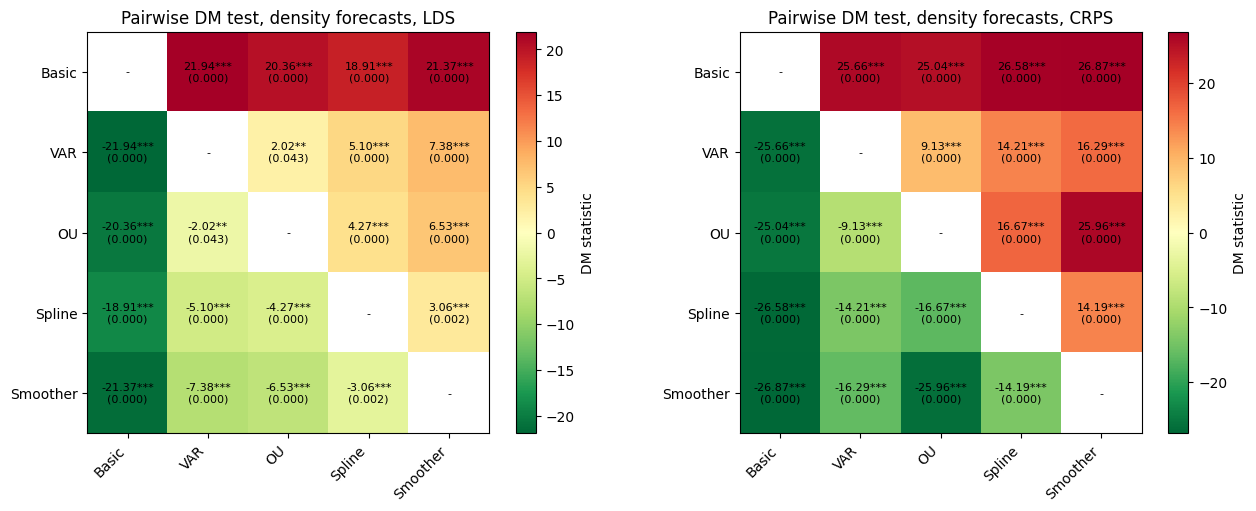

In [13]:
# Pairwise DM tests for LDS
dm_lds, p_lds, names = pairwise_dm_matrices({
    "Basic": lds_df["Basic"],
    "VAR": lds_df["VAR"],
    "OU": lds_df["OU"],
    "Spline": lds_df["Spline"],
    "Smoother": lds_df["NN"]
}, lag=5)

# Pairwise DM tests for CRPS
dm_crps, p_crps, _ = pairwise_dm_matrices({
    "Basic": crps_df["Basic"],
    "VAR": crps_df["VAR"],
    "OU": crps_df["OU"],
    "Spline": crps_df["Spline"],
    "Smoother": crps_df["NN"]
}, lag=5)

# Specify colormap
cmap = plt.colormaps["RdYlGn_r"].copy()
cmap.set_bad("white")

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# Draw LDS heatmap
im_lds = add_dm_heatmap(axes[0], dm_lds, p_lds, names, "Pairwise DM test, density forecasts, LDS", cmap)

# Draw CRPS heatmap
im_crps = add_dm_heatmap(axes[1], dm_crps, p_crps, names, "Pairwise DM test, density forecasts, CRPS", cmap)

# Add colorbars
fig.colorbar(im_lds, ax=axes[0], label="DM statistic")
fig.colorbar(im_crps, ax=axes[1], label="DM statistic")

# Plot and save
plt.savefig("/Users/euanbronsky/Downloads/heatmap.rnd.dm2.png", bbox_inches="tight")
plt.show()

# **2. Plots of the risk-neutral densities**

-------------------------------------

Risk-neutral densities are plotted to provide a visual interpretation of the distributional information implied by option prices. They show how the market assigns probability mass to different future underlying values under the risk-neutral measure. This helps illustrate stylized features of option pricing, such as skewness, fat tails, and shifts in maturity uncertainty.

- **Black-Scholes call helper function**

In [14]:
# Black-Scholes function
def bs_call(S, K, r, q, T, sigma):

    # Compute d1
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

    # Compute d2
    d2 = d1 - sigma * np.sqrt(T)

    # Return the call price
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

- **Compute risk-neutral densities from groups**

Instead of finite differences, a smooth spline is fitted to the model-implied call price curve. The risk-neutral density is then obtained by taking the second derivative of this fitted spline on a fine strike grid. This produces a smoother and more visually interpretable density estimate.

In [15]:
# RND function
def rnd_from_group(g, iv_col):

    # Sort data by strike and collapse duplicate strikes
    g = (
        g.sort_values("strike")
        .groupby("strike", as_index=False)
        .agg({
            "underlying_last": "first",
            "r": "first",
            "q": "first",
            "T": "first",
            iv_col: "mean"}))

    # Take the first values
    S = g["underlying_last"].iloc[0]
    r = g["r"].iloc[0]
    q = g["q"].iloc[0]
    T = g["T"].iloc[0]

    # Convert to NumPy arrays
    K = g["strike"].to_numpy()
    iv = np.maximum(g[iv_col].to_numpy(), 1e-4)

    # Compute BS price
    C = bs_call(S, K, r, q, T, iv)

    # Create fine grid of strike prices
    K_grid = np.linspace(K.min(), K.max(), 700)

    # Fit a smooth spline curve through call prices
    c_spline = UnivariateSpline(K, C, s=1e-6 * len(K) * np.var(C), k=3)

    # Estimate the risk-neutral density
    density = np.exp(r * T) * c_spline.derivative(2)(K_grid)
    density = np.maximum(density, 0)

    # Normalize the density so that the total area under it equals 1
    area = np.trapezoid(density, K_grid)
    if area > 0:
        density = density / area

    # Convert strike grid into log-moneyness
    x_grid = np.log(K_grid / S)
    #x_grid = np.log(K_grid / (np.exp(r * T) * S)) / np.sqrt(T)

    # Return the results
    return x_grid, density, T

- **Prepare data for plotting**

In [16]:
# Models to plot
models = ["VAR", "OU", "Spline", "NN"]
model_titles = {
    "VAR": "VAR",
    "OU": "OU",
    "Spline": "Spline",
    "NN": "Smoother"}

# Build base dataframe from Spline
x_base, _ = eval_results["Spline"]

# Copy DataFrame and reset index
df_plot = x_base.copy().reset_index(drop=True)

# Convert to datetime
df_plot["quote_date"] = pd.to_datetime(df_plot["quote_date"])
df_plot["expire_date"] = pd.to_datetime(df_plot["expire_date"])

# Remove duplicate rows
df_plot = (
    df_plot
    .groupby(["quote_date", "expire_date", "strike"], as_index=False)
    .agg({
        "underlying_last": "first",
        "r": "first",
        "q": "first",
        "T": "first"}))

# Add predictions from each model
for model in models:

    # Extract results for one specific model
    x_m, iv_m = eval_results[model]

    # Copy, add model's IV prediction as new column, and ensure datetime
    tmp = x_m.copy().reset_index(drop=True)
    tmp[f"iv_{model}"] = np.asarray(iv_m, dtype=float)
    tmp["quote_date"] = pd.to_datetime(tmp["quote_date"])
    tmp["expire_date"] = pd.to_datetime(tmp["expire_date"])

    # Collapse duplicate strike rows
    tmp = (
        tmp
        .groupby(["quote_date", "expire_date", "strike"], as_index=False)
        .agg({f"iv_{model}": "mean"}))

    # Merge the model's IV column into df_plot
    df_plot = df_plot.merge(tmp, on=["quote_date", "expire_date", "strike"], how="inner")

# Choose quote date
quote_date = df_plot["quote_date"].drop_duplicates().iloc[910]
df_q = df_plot[df_plot["quote_date"].eq(quote_date)].copy()

# Create empty list
groups = []

# Split data by expiry date
for expiry, g in df_q.groupby("expire_date"):

    # Keep only expiries with enough observations
    if len(g) >= 8 and g["T"].iloc[0] > 0:
        groups.append((expiry, g))

# Color scale
all_T = np.array([g["T"].iloc[0] for _, g in groups])
norm_t = Normalize(vmin=all_T.min(), vmax=all_T.max())
cmap = plt.cm.Blues

- **Color helper function**

In [17]:
# Maturity color
def maturity_color(T):

    # Return the result
    return cmap(0.25 + 0.70 * norm_t(T))

- **Plot the risk neutral densities**

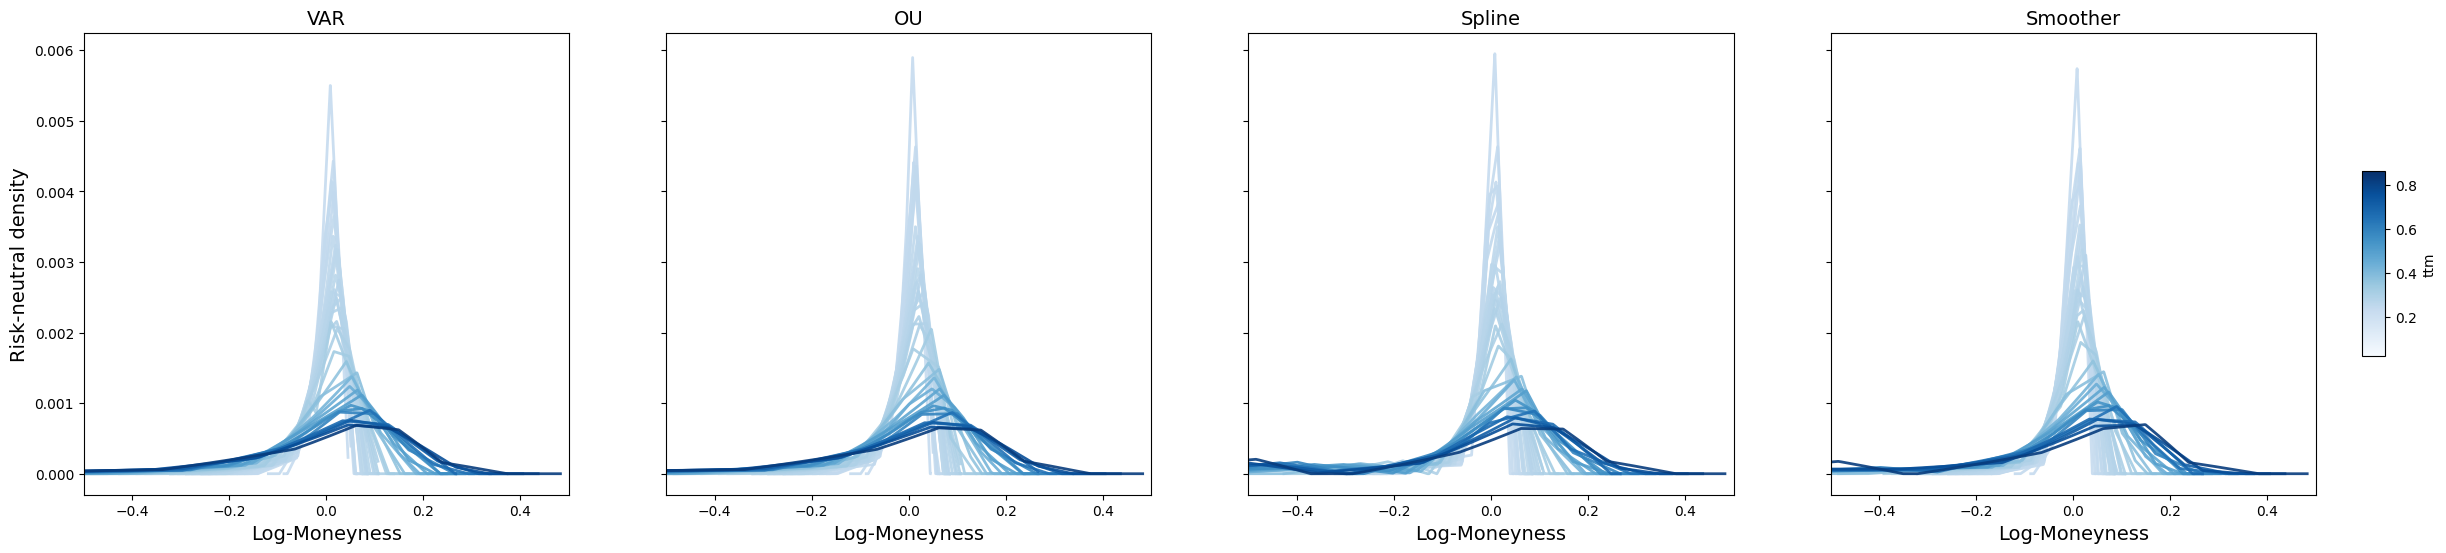

In [18]:
# Set plotting environment
fig, axes = plt.subplots(1, 4, figsize=(30, 6), sharey=True)

# Loop over axes
for ax, model in zip(axes, models):

    # Loop over expiries
    for expiry, g in groups:

        # Call function for one expiry and model
        x_grid, density, T = rnd_from_group(g, f"iv_{model}")

        # Plot the variables
        ax.plot(x_grid, density, color=maturity_color(T), linewidth=2.0, alpha=0.9)

    # Set titles
    ax.set_title(model_titles[model], fontsize=14)
    ax.set_xlabel("Log-Moneyness", fontsize=14)
    ax.set_xlim(-0.5, 0.5)

# Set one common y-label
axes[0].set_ylabel("Risk-neutral density", fontsize=14)

# Coloring
sm = ScalarMappable(norm=norm_t, cmap=cmap)
sm.set_array([])

# Colorbar
cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02, shrink=0.4, aspect=8)
cbar.set_label("ttm")

# Plot the results
plt.savefig("/Users/euanbronsky/Downloads/rn.densities2.png", bbox_inches="tight")
plt.show()

# **3. Value-at-Risk backtest**
---------------------------------

This section evaluates the models from a risk-management perspective using a Value-at-Risk backtest. The one-step-ahead VaR forecast is given by

$$\widehat{VaR}_{\alpha,t \mid t-1}
=
\tilde P_{t\mid t-1}
+
\frac{Q(\alpha)}{N_t}
\sqrt{
\iota_{N_t}^{\top}
{F}_t
\iota_{N_t}
}$$

The matrix $F_t$ aggregates both latent-factor uncertainty and residual uncertainty and is computed as

$$    {F}_t = M_t P_{t|t-1}^\beta M_t^\top + H_t$$

By counting how often the realized outcome falls below the predicted VaR threshold, the backtest assesses whether the models produce tail-risk forecasts with appropriate coverage.

- **Load the data**

In [19]:
# Basic model
with open("/Users/euanbronsky/PyCharmMiscProject/1first_results.pkl", "rb") as f:
    static_results = pickle.load(f)

# VAR model
with open("/Users/euanbronsky/PyCharmMiscProject/2model1_results.pkl", 'rb') as f:
    var_results = pickle.load(f)

# OU model
with open('/Users/euanbronsky/PyCharmMiscProject/3model_ou_results.pkl', 'rb') as f:
    ou_results = pickle.load(f)

# Spline model
with open("/Users/euanbronsky/PyCharmMiscProject/4spline_results.pkl", "rb") as f:
    spline_results = pickle.load(f)

# NN
with open("/Users/euanbronsky/PyCharmMiscProject/x_test_nn.pkl", "rb") as f:
    nn_results = pickle.load(f)

# Save with Pickle
with open("/Users/euanbronsky/PyCharmMiscProject/models.eval.pkl", "rb") as f:
    models = pickle.load(f)

- **Kupiec unconditional coverage test function**

The Kupiec likelihood-ratio test statistic is then given by

$$LR
=
2 \cdot |\mathcal{T}_{test}| \cdot \log \bigl(
\bigl( \frac{1 - \hat p}{1 - \alpha} \bigr)^{1-\hat p}
\bigl( \frac{\hat p}{\alpha} \bigr)^{\hat p}
\bigr)$$

In [20]:
# Kupiec unconditional coverage test function
def kupiec_uc_test_from_hits(hits, alpha):

    # Define hits variable
    hits = np.asarray(hits, dtype=int)

    # Sample size, VaR violations, and empirical violation rate
    T = len(hits)
    x = int(hits.sum())
    p_hat = x / T

    # No violations
    if x == 0:
        LR_uc = -2 * T * np.log(1 - alpha)

    # Every observation is a violation
    elif x == T:
        LR_uc = -2 * T * np.log(alpha)

    # Normal case
    else:
        LR_uc = 2 * (x * np.log(p_hat / alpha) + (T - x) * np.log((1 - p_hat) / (1 - alpha)))

    # Compute p-value
    p_value = 1 - chi2.cdf(LR_uc, df=1)

    # Return the results
    return LR_uc, p_value

- **Christoffersen conditional coverage test function**

The conditional coverage likelihood-ratio statistic is defined as

\begin{equation}
    LR_{cc}
    =
    2\left[\log \mathcal{L}(\Pi_2) - \log \mathcal{L}(\alpha)\right]
    +
    2\left[\log \mathcal{L}(\Pi_1) - \log \mathcal{L}(\Pi_2)\right]
    \sim \chi^2(2).
\end{equation}

In [21]:
# Christoffersen conditional coverage test
def christoffersen_cc_test_from_hits(hits, alpha):

    # Hit variable
    hits = np.asarray(hits, dtype=int)

    # Create yesterday-today pairs of violations
    h0 = hits[:-1]
    h1 = hits[1:]

    # Count how many times each transition happens
    n00 = np.sum((h0 == 0) & (h1 == 0))
    n01 = np.sum((h0 == 0) & (h1 == 1))
    n10 = np.sum((h0 == 1) & (h1 == 0))
    n11 = np.sum((h0 == 1) & (h1 == 1))

    # Total number of transitions
    Tm1 = n00 + n01 + n10 + n11

    # Count number of times second observation is a violation
    x = n01 + n11

    # Compute overall violation probability
    pi_hat = x / Tm1

    # Compute the unconditional coverage part
    if x == 0:
        LR_uc = -2 * Tm1 * np.log(1 - alpha)
    elif x == Tm1:
        LR_uc = -2 * Tm1 * np.log(alpha)
    else:
        LR_uc = 2 * (x * np.log(pi_hat / alpha) + (Tm1 - x) * np.log((1 - pi_hat) / (1 - alpha)))

    # Compute transition probabilities
    p01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0.0
    p11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0

    # Define log-likelihood component
    def ll(count, prob):
        return 0.0 if count == 0 else count * np.log(prob)

    # Compute Markov log-likelihood
    logL_markov = (ll(n00, 1 - p01) + ll(n01, p01) + ll(n10, 1 - p11) + ll(n11, p11))

    # Compute iid log-likelihood
    logL_iid = (ll(n00 + n10, 1 - pi_hat) + ll(n01 + n11, pi_hat))

    # Compute independence LR statistic
    LR_ind = 2 * (logL_markov - logL_iid)

    # Compute conditional coverage statistic
    LR_cc = LR_uc + LR_ind

    # Compute p-value
    p_cc = 1 - chi2.cdf(LR_cc, df=2)

    # Return the results
    return LR_cc, p_cc

- **Tick-loss function**

The tick loss is reported to evaluate the accuracy of the predicted VaR quantile, and is given by

$$
    TL_{\alpha,t} = (\alpha - \mathbb{I}\{ \tilde P_t < \widehat{VaR}_{\alpha, t|t-1}\})(\tilde P_t - \widehat{VaR}_{\alpha, t|t-1})
$$

In [22]:
# Tick loss
def tick_loss(y, q, alpha):

    # Return the results
    return (alpha - (y < q).astype(int)) * (y - q)

- **Value-at-Risk backtest**

In [23]:
# Value-at-Risk backtest
def var_backtest(x_test, pred_col, results, alpha=0.01):

    # Copy the DataFrame
    x_test = x_test.copy()

    # Convert to datetime and log implied volatility
    x_test["quote_date"] = pd.to_datetime(x_test["quote_date"])
    x_test["log_iv_pred"] = np.log(x_test[pred_col])

    # Compute average predicted and observed log implied volatility
    avg_pred = x_test.groupby("quote_date")["log_iv_pred"].mean()
    avg_obs = x_test.groupby("quote_date")["log_iv"].mean()

    # Ensure correct bucket order
    bucket_order = (
        x_test[["moneyness_group", "maturity_group"]]
        .drop_duplicates()
        .sort_values(["moneyness_group", "maturity_group"])
        .reset_index(drop=True))

    # Assign residual variance by bucket
    bucket_order["h_var"] = results["sigma2"]

    # Merge residual variances into test data
    x_test = x_test.merge(bucket_order, on=["moneyness_group", "maturity_group"], how="left")

    # Extract predicted state covariance matrices
    Pt_pred_all = pd.Series(list(results["Pt_pred"]), index=pd.to_datetime(results["dates"]))

    # Compute alpha quantile and extract basis columns
    Q_alpha = norm.ppf(alpha)
    basis_cols = results["basis_cols"]
    var_pred = {}

    # Loop over dates
    for date, group in x_test.groupby("quote_date"):

        # Convert to datetime
        date = pd.to_datetime(date)

        # Skip if covariance matrix is unavailable
        if date not in Pt_pred_all.index:
            continue

        # Build forecast-error covariance components
        M_t = group[basis_cols].to_numpy()
        P_t = Pt_pred_all.loc[date]
        H_t = np.diag(group["h_var"].to_numpy())

        # Construct forecast-error covariance matrix
        F_t = M_t @ P_t @ M_t.T + H_t

        # Compute standard deviation of cross-sectional average forecast error
        N_t = len(group)
        iota = np.ones(N_t)
        sd_avg = np.sqrt((iota @ F_t @ iota) / N_t ** 2)

        # Compute VaR threshold
        var_pred[date] = avg_pred.loc[date] + Q_alpha * sd_avg

    # Return VaR forecasts and observed average log IV
    var_pred = pd.Series(var_pred)

    return var_pred, avg_obs

# Convert RND common index to quote-date index for VaR
var_common_dates = pd.to_datetime(common_idx.get_level_values("quote_date").unique())

- **Call the functions on the aligned sample**

In [24]:
# Create list of alphas
alphas = [0.01, 0.05, 0.10]

# Model specifications
model_specs = {
    "VAR": {
        "x_test": models["VAR"][0].copy(),
        "pred": models["VAR"][1],
        "pred_col": "iv_var",
        "results": var_results
    },
    "OU": {
        "x_test": models["OU"][0].copy(),
        "pred": models["OU"][1],
        "pred_col": "iv_ou",
        "results": ou_results
    },
    "Spline": {
        "x_test": models["Spline"][0].copy(),
        "pred": models["Spline"][1],
        "pred_col": "iv_spline",
        "results": spline_results
    },
    "NN": {
        "x_test": models["NN"][0].copy(),
        "pred": None,
        "pred_col": "iv_nn",
        "results": spline_results}}

# Empty containers
avg_obs_store = {}
var_store = {}

# Compute VaR forecasts
for model_name, spec in model_specs.items():

    # Copy DataFrame
    x_test = spec["x_test"].copy()

    # Add prediction column if predictions are stored separately
    if spec["pred"] is not None:
        x_test[spec["pred_col"]] = spec["pred"]

    # Compute VaR forecasts for each alpha
    for alpha in alphas:

        # Run VaR function
        var_pred, avg_obs = var_backtest(x_test=x_test, pred_col=spec["pred_col"], results=spec["results"], alpha=alpha)

        # Store outputs
        var_store[(model_name, alpha)] = var_pred
        avg_obs_store[model_name] = avg_obs

# Align VaR sample to density-forecast common quote dates
aligned_var_idx = var_common_dates

# Obtain indices
for key in var_store:
    aligned_var_idx = aligned_var_idx.intersection(
        var_store[key].dropna().index)

# Align indices
for model_name in avg_obs_store:
    aligned_var_idx = aligned_var_idx.intersection(
        avg_obs_store[model_name].dropna().index)

# Create empty containers for aligned results
backtest_rows = []
violations_store = {}
tick_loss_store = {}

# Compute aligned VaR results
for model_name in model_specs:

    # Extract observed average log IV
    avg_obs = avg_obs_store[model_name]

    # Loop over VaR levels
    for alpha in alphas:
        # Extract VaR forecasts
        var_pred = var_store[(model_name, alpha)]

        # Extract aligned observations and VaR forecasts
        y = avg_obs.loc[aligned_var_idx].to_numpy()
        q = var_pred.loc[aligned_var_idx].to_numpy()

        # Compute violations and tick losses
        violations = (y < q).astype(int)
        losses = tick_loss(y, q, alpha)

        # Conduct coverage tests
        LR_uc, p_uc = kupiec_uc_test_from_hits(violations, alpha)
        LR_cc, p_cc = christoffersen_cc_test_from_hits(violations, alpha)

        # Store table row
        backtest_rows.append({
            "model": model_name,
            "alpha": alpha,
            "violation_rate": violations.mean(),
            "n_violations": int(violations.sum()),
            "n_obs": len(violations),
            "tick_loss": losses.mean(),
            'total_tick_loss': losses.sum(),
            "LR_uc": LR_uc,
            "p_uc": p_uc,
            "LR_cc": LR_cc,
            "p_cc": p_cc})

        # Store aligned series
        violations_store[(model_name, alpha)] = pd.Series(violations, index=aligned_var_idx, name="violation")

        tick_loss_store[(model_name, alpha)] = pd.Series(losses, index=aligned_var_idx, name="tick_loss")

# Display aligned VaR backtest results
backtest_results = pd.DataFrame(backtest_rows)
backtest_results = backtest_results[
    ["model", "alpha", "violation_rate", "n_violations", "n_obs", "tick_loss", 'total_tick_loss', "LR_uc", "p_uc", "LR_cc", "p_cc"]]
print(backtest_results)

     model  alpha  violation_rate  n_violations  n_obs  tick_loss  \
0      VAR   0.01        0.014122            16   1133   0.002237   
1      VAR   0.05        0.046778            53   1133   0.008886   
2      VAR   0.10        0.079435            90   1133   0.015301   
3       OU   0.01        0.000000             0   1133   0.001912   
4       OU   0.05        0.005296             6   1133   0.007896   
5       OU   0.10        0.011474            13   1133   0.014076   
6   Spline   0.01        0.000883             1   1133   0.002912   
7   Spline   0.05        0.001765             2   1133   0.012505   
8   Spline   0.10        0.003530             4   1133   0.022878   
9       NN   0.01        0.000883             1   1133   0.001530   
10      NN   0.05        0.002648             3   1133   0.005722   
11      NN   0.10        0.012357            14   1133   0.009381   

    total_tick_loss       LR_uc      p_uc       LR_cc      p_cc  
0          2.534601    1.723779  0.1

- **Tick-loss DM heatmaps**

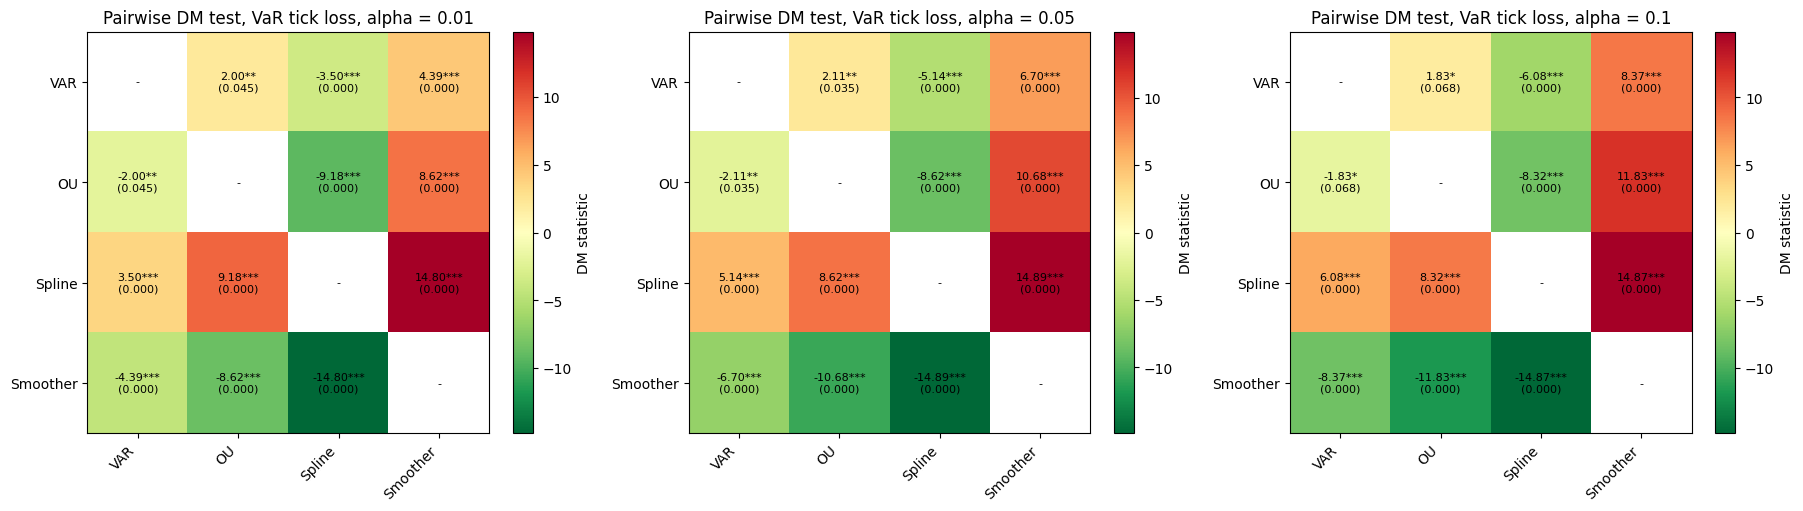

In [25]:
# Pairwise DM tests for each alpha
dm_tick = {}
p_tick = {}

# Loop over the alpha levels
for alpha in alphas:

    # Run pairwise DM tests
    dm_tick[alpha], p_tick[alpha], names = pairwise_dm_matrices({
        "VAR": tick_loss_store[("VAR", alpha)],
        "OU": tick_loss_store[("OU", alpha)],
        "Spline": tick_loss_store[("Spline", alpha)],
        "Smoother": tick_loss_store[("NN", alpha)]
    }, lag=5)

# Specify colormap
cmap = plt.colormaps["RdYlGn_r"].copy()
cmap.set_bad("white")

# Set plotting environment
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# Draw tick-loss heatmaps
ims = []

# Loop over axes
for ax, alpha in zip(axes, alphas):

    # Draw heatmap
    im = add_dm_heatmap(ax, dm_tick[alpha], p_tick[alpha], names, f"Pairwise DM test, VaR tick loss, alpha = {alpha}", cmap)
    ims.append(im)

# Add color bars
for ax, im in zip(axes, ims):
    fig.colorbar(im, ax=ax, label="DM statistic")

# Plot and save
plt.savefig("/Users/euanbronsky/Downloads/heatmap.var.tickloss.dm2.png", bbox_inches="tight")
plt.show()